# Day 22 — Transformers
## Hands-on Introduction with Hugging Face

### Objective
Understand how a Transformer model is used for a real NLP task.

We will:
- Use a pre-trained Transformer
- Perform sentiment analysis
- Inspect predictions and model scores
- Inspect Transformer tokenization
- Understand the Transformer workflow
- Compare Transformer NLP with the Day 21 TF-IDF approach

### Core idea

Text → Tokenizer → Transformer → Prediction


## 1. Install and Import Hugging Face Transformers

In [ ]:
!pip -q install transformers

from transformers import pipeline
import pandas as pd
import matplotlib.pyplot as plt


## 2. Create a Sentiment Analysis Pipeline

Hugging Face's `pipeline()` provides a simple interface for using a pre-trained Transformer model.

The model has already been trained, so this notebook focuses on **inference** and understanding the workflow.

In [ ]:
sentiment_pipeline = pipeline("sentiment-analysis")


[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

## 3. First Prediction

In [ ]:
text = "I absolutely love this product!"

result = sentiment_pipeline(text)

print(result)


[{'label': 'POSITIVE', 'score': 0.9998854398727417}]


## 4. Understand the Output

The result normally contains:
- `label` → predicted class
- `score` → estimated model probability/confidence for that predicted class

A high score does not guarantee that the prediction is correct.

In [ ]:
result = sentiment_pipeline("The product quality is excellent!")[0]

print("Label:", result["label"])
print("Score:", result["score"])


Label: POSITIVE
Score: 0.9998764991760254


## 5. Test Multiple Reviews

In [ ]:
reviews = [
    "This product is amazing!",
    "I really enjoyed the experience.",
    "The quality is terrible.",
    "I am very disappointed.",
    "The product arrived today."
]

results = sentiment_pipeline(reviews)

for review, result in zip(reviews, results):
    print(f"Review: {review}")
    print(f"Prediction: {result['label']}")
    print(f"Score: {result['score']:.4f}")
    print("-" * 60)


Review: This product is amazing!
Prediction: POSITIVE
Score: 0.9999
------------------------------------------------------------
Review: I really enjoyed the experience.
Prediction: POSITIVE
Score: 0.9999
------------------------------------------------------------
Review: The quality is terrible.
Prediction: NEGATIVE
Score: 0.9997
------------------------------------------------------------
Review: I am very disappointed.
Prediction: NEGATIVE
Score: 0.9998
------------------------------------------------------------
Review: The product arrived today.
Prediction: POSITIVE
Score: 0.9983
------------------------------------------------------------


## 6. Store Predictions in a DataFrame

In [ ]:
result_df = pd.DataFrame({
    "review": reviews,
    "label": [r["label"] for r in results],
    "score": [r["score"] for r in results]
})

result_df


,review,label,score
0,This product is amazing!,POSITIVE,0.999886
1,I really enjoyed the experience.,POSITIVE,0.999876
2,The quality is terrible.,NEGATIVE,0.999719
3,I am very disappointed.,NEGATIVE,0.999775
4,The product arrived today.,POSITIVE,0.998311


## 7. Visualize Prediction Scores

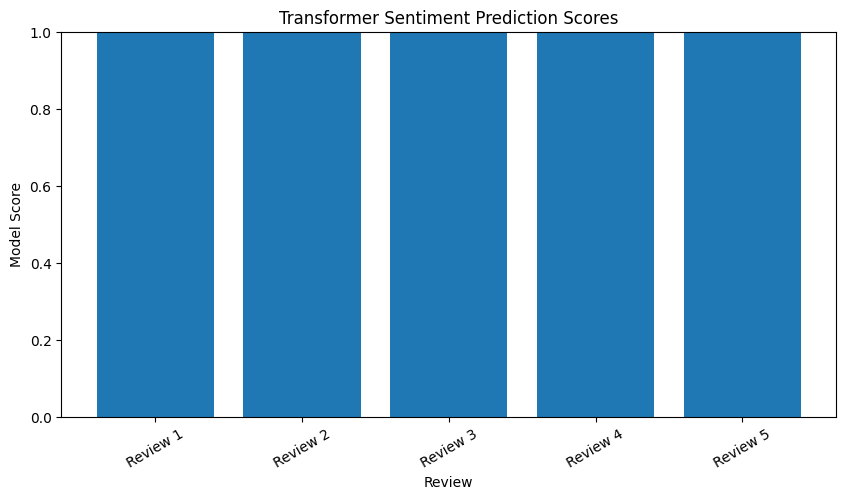

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(range(len(result_df)), result_df["score"])
plt.xticks(
    range(len(result_df)),
    [f"Review {i+1}" for i in range(len(result_df))],
    rotation=30
)
plt.ylabel("Model Score")
plt.xlabel("Review")
plt.title("Transformer Sentiment Prediction Scores")
plt.ylim(0, 1)
plt.show()


## 8. Try Your Own Text

Change `custom_text` and run the cell.

In [ ]:
custom_text = "The product is fantastic and I am very happy with it."

custom_result = sentiment_pipeline(custom_text)[0]

print("Text:", custom_text)
print("Prediction:", custom_result["label"])
print("Score:", round(custom_result["score"], 4))


Text: The product is fantastic and I am very happy with it.
Prediction: POSITIVE
Score: 0.9999


# 9. What Happens Internally?

The high-level pipeline hides several important steps.

Conceptually:

```text
Raw Text
   ↓
Tokenizer
   ↓
Token IDs
   ↓
Transformer
   ↓
Contextual Representations
   ↓
Classification Head
   ↓
Sentiment
```

The tokenizer converts text into a representation that the neural network can process.

The Transformer uses attention to model relationships between tokens.

## 10. Tokenization

In [ ]:
tokenizer = sentiment_pipeline.tokenizer

sample_text = "I love learning about Transformers!"

tokens = tokenizer.tokenize(sample_text)
token_ids = tokenizer.encode(sample_text)

print("Text:", sample_text)
print("\nTokens:")
print(tokens)

print("\nToken IDs:")
print(token_ids)


Text: I love learning about Transformers!

Tokens:
['i', 'love', 'learning', 'about', 'transformers', '!']

Token IDs:
[101, 1045, 2293, 4083, 2055, 19081, 999, 102]


## 11. Why Tokenization Matters

A Transformer does not directly receive a Python string.

It receives numerical token representations.

```text
"I love AI"
    ↓
Tokens
    ↓
Token IDs
    ↓
Transformer
```

Modern tokenizers may split words into **subword tokens**, which helps models handle uncommon words.

# 12. Self-Attention — Conceptual Understanding

Consider:

> "The animal didn't cross the road because it was tired."

Attention allows the model to examine relationships between tokens and surrounding context.

The key idea:

**Self-attention lets each token representation incorporate information from other relevant tokens in the same sequence.**


# 13. Transformer vs Day 21

### Day 21

```text
Text
 ↓
Preprocessing
 ↓
TF-IDF
 ↓
Logistic Regression
 ↓
Sentiment
```

### Day 22

```text
Text
 ↓
Tokenizer
 ↓
Pre-trained Transformer
 ↓
Sentiment
```

The Transformer uses learned contextual representations instead of a simple word-count/TF-IDF representation.

# 14. Transformer Families

### Encoder-only
Example: **BERT**

Commonly used for language understanding.

### Decoder-only
Examples: **GPT-style models**

Commonly used for text generation.

### Encoder-Decoder
Example: **T5**

Commonly used for sequence-to-sequence tasks such as translation and summarization.

# 15. Important Concepts

| Concept | Meaning |
|---|---|
| Tokenizer | Converts text into model-readable tokens |
| Attention | Models relationships between token representations |
| Self-Attention | Attention within the same sequence |
| Query | What information a token is looking for |
| Key | Information used for matching |
| Value | Information passed through attention |
| Multi-Head Attention | Multiple attention patterns |
| Positional Information | Represents token order |
| Encoder | Builds contextual representations |
| Decoder | Produces/generates output representations or tokens |


# 16. Simplified Transformer Block

```text
Input Tokens
     ↓
Token Embeddings
     +
Positional Information
     ↓
Multi-Head Self-Attention
     ↓
Add & Normalize
     ↓
Feed Forward Network
     ↓
Add & Normalize
     ↓
Output
```

Multiple Transformer blocks can be stacked to build larger models.

## 17. Practice — Test Different Sentiments

In [ ]:
practice_reviews = [
    "The camera is excellent but the battery is terrible.",
    "I do not like this product.",
    "Amazing! My laptop crashed again.",
    "The package arrived today.",
    "This is one of the best products I have purchased."
]

practice_results = sentiment_pipeline(practice_reviews)

for review, result in zip(practice_reviews, practice_results):
    print("Review:", review)
    print("Prediction:", result["label"])
    print("Score:", round(result["score"], 4))
    print("-" * 60)


Review: The camera is excellent but the battery is terrible.
Prediction: NEGATIVE
Score: 0.9935
------------------------------------------------------------
Review: I do not like this product.
Prediction: NEGATIVE
Score: 0.9982
------------------------------------------------------------
Review: Amazing! My laptop crashed again.
Prediction: POSITIVE
Score: 0.9964
------------------------------------------------------------
Review: The package arrived today.
Prediction: POSITIVE
Score: 0.9975
------------------------------------------------------------
Review: This is one of the best products I have purchased.
Prediction: POSITIVE
Score: 0.9999
------------------------------------------------------------


## 18. Practice — Batch Prediction

In [ ]:
my_reviews = [
    "The delivery was fast and the product is excellent.",
    "The product stopped working after one day.",
    "The service was okay."
]

my_results = sentiment_pipeline(my_reviews)

for review, result in zip(my_reviews, my_results):
    print(f"{result['label']} ({result['score']:.3f}) → {review}")


POSITIVE (1.000) → The delivery was fast and the product is excellent.
NEGATIVE (1.000) → The product stopped working after one day.
POSITIVE (1.000) → The service was okay.


# 19. Key Takeaways

- Transformers are attention-based neural network architectures.
- They are central to modern NLP.
- Tokenization converts text into model-readable tokens.
- Self-attention helps model relationships between tokens.
- Multi-head attention learns multiple attention patterns.
- BERT is an encoder-focused Transformer model.
- GPT-style models are decoder-focused.
- T5 is an encoder-decoder Transformer model.
- Hugging Face provides convenient APIs for using pre-trained Transformer models.

### Core Concept

**Text → Tokenizer → Transformer → Contextual Understanding → Task Output**
